# Colorado Fire Data Extraction Pipeline

This notebook orchestrates data extraction from three sources for Colorado wildfire analysis:

| Step | Source | Script | Output |
|------|--------|--------|--------|
| 1 | MTBS (fire perimeters) | `fetch_mtbs.py` | `mtbs_colorado.csv`, `mtbs_colorado.geojson` |
| 2 | SRTM (elevation) | `fetch_srtm.py` | topo sampled at fire centroids |
| 3 | GridMET (climate) | `fetch_gridmet.py` | `gridmet_colorado_climate.csv` |

**Prerequisites:**
- Google Earth Engine account authenticated (`ee.Authenticate()`)
- EE project registered: `fire-344-467415`
- Python packages: `earthengine-api`, `geemap`, `pandas`, `matplotlib`

## Step 0 — Imports and Earth Engine Authentication

Import all modules from the three fetch scripts and initialize Earth Engine.  
Run `ee.Authenticate()` only once — credentials are cached after the first run.

In [1]:
import sys
import os
import ee
import pandas as pd
import matplotlib.pyplot as plt

# Add the code directory to path (where fetch_*.py scripts live)
sys.path.insert(0, os.getcwd())

# Import functions from each fetch script
from fetch_mtbs import get_colorado_boundary, load_mtbs, mtbs_to_dataframe, save_geojson
from fetch_srtm import build_topo_image, summarize_topo_for_colorado, sample_topo_at_points
from fetch_gridmet import extract_daily_means, extract_fire_weather, aggregate_monthly

EE_PROJECT = "fire-344-467415"

# Authenticate once — comment out after first successful run
# ee.Authenticate()

ee.Initialize(project=EE_PROJECT)
print("Earth Engine initialized successfully.")

/opt/conda/envs/macrosystems/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Earth Engine initialized successfully.


---
## Step 1 — MTBS Fire Perimeters (Colorado, 2000–2023)

**Source:** USFS Monitoring Trends in Burn Severity (MTBS)  
**EE Asset:** `USFS/GTAC/MTBS/burned_area_boundaries/v1`  
**What we extract:** Fire name, ignition date, fire year, burned area, fire type, perimeter geometry  
**Outputs:** `mtbs_colorado.csv` and `mtbs_colorado.geojson`

In [13]:
START_YEAR = 2000
END_YEAR   = 2000

colorado = get_colorado_boundary()
fires_fc  = load_mtbs(colorado, START_YEAR, END_YEAR)

# Convert once — avoids a second .getInfo() round-trip
df_mtbs = mtbs_to_dataframe(fires_fc)
df_mtbs.to_csv("mtbs_colorado.csv", index=False)

print(f"Total fires: {len(df_mtbs)}")
print(f"Shape:       {df_mtbs.shape}")
print(f"Columns:     {df_mtbs.columns.tolist()}")
df_mtbs.head()

Total fires: 23
Shape:       (23, 24)
Columns:     ['Asmnt_Type', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon', 'Comment', 'Event_ID', 'High_T', 'Ig_Date', 'IncGreen_T', 'Incid_Name', 'Incid_Type', 'Low_T', 'Map_ID', 'Map_Prog', 'Mod_T', 'NoData_T', 'Perim_ID', 'Post_ID', 'Pre_ID', 'dNBR_offst', 'dNBR_stdDv', 'fire_year', 'irwinID', 'geometry_type']


,Asmnt_Type,BurnBndAc,BurnBndLat,BurnBndLon,Comment,Event_ID,High_T,Ig_Date,IncGreen_T,Incid_Name,...,Mod_T,NoData_T,Perim_ID,Post_ID,Pre_ID,dNBR_offst,dNBR_stdDv,fire_year,irwinID,geometry_type
0,Extended,2747,38.195,-105.024,,CO3819510502420000409,470,955263600000,-150,PSFRXASST1,...,254,-970,703303420000509,703303420000610,503303419960607,-23,-9999,2000,,Polygon
1,Initial (SS),5555,37.803,-103.106,,CO3780310310620000907,-9999,968310000000,9999,UNNAMED,...,-9999,9999,,703203420000907,,-9999,-9999,2000,,Polygon
2,Initial (SS),1304,38.973,-102.138,,CO3897310213820000425,-9999,956646000000,9999,UNNAMED,...,-9999,9999,,703103320000425,,-9999,-9999,2000,,Polygon
3,Extended,1150,37.531,-108.883,,CO3753110888320000722,385,964249200000,-150,HOVENWEEP,...,208,-970,703503420000912,703503420010611,703503420000523,27,-9999,2000,,Polygon
4,Extended,2704,37.991,-108.524,,CO3799110852420000806,420,965545200000,-150,HAMILTON,...,232,-970,703503420000912,703503420010611,703503420000523,27,-9999,2000,,MultiPolygon


In [4]:
# Convert to DataFrame and save
df_mtbs = mtbs_to_dataframe(fires_fc)
df_mtbs.to_csv("mtbs_colorado.csv", index=False)

print(f"Shape:   {df_mtbs.shape}")
print(f"Columns: {df_mtbs.columns.tolist()}")
df_mtbs.head()

Shape:   (348, 24)
Columns: ['Asmnt_Type', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon', 'Comment', 'Event_ID', 'High_T', 'Ig_Date', 'IncGreen_T', 'Incid_Name', 'Incid_Type', 'Low_T', 'Map_ID', 'Map_Prog', 'Mod_T', 'NoData_T', 'Perim_ID', 'Post_ID', 'Pre_ID', 'dNBR_offst', 'dNBR_stdDv', 'fire_year', 'irwinID', 'geometry_type']


,Asmnt_Type,BurnBndAc,BurnBndLat,BurnBndLon,Comment,Event_ID,High_T,Ig_Date,IncGreen_T,Incid_Name,...,Mod_T,NoData_T,Perim_ID,Post_ID,Pre_ID,dNBR_offst,dNBR_stdDv,fire_year,irwinID,geometry_type
0,Extended,2747,38.195,-105.024,,CO3819510502420000409,470,955263600000,-150,PSFRXASST1,...,254,-970,703303420000509,703303420000610,503303419960607,-23,-9999,2000,,Polygon
1,Extended,6773,37.079,-107.304,,CO3707910730420010503,9999,988873200000,-150,SANDOVAL,...,195,-970,503403420010527,703403420020506,503403419990506,10,-9999,2001,,Polygon
2,Extended,1226,37.098,-107.199,,CO3709810719920101012,9999,1286866800000,-150,REDONDA II RX,...,250,-970,,503403420110608,503403420100605,-6,-9999,2010,,Polygon
3,Extended,1327,37.445,-106.822,,CO3743010682020130927,605,1380265200000,-150,UNNAMED,...,342,-970,803403420131003,803403420140616,503403420100621,-45,-9999,2013,,Polygon
4,Extended,3960,37.108,-107.234,,CO3709810721320160910,500,1473490800000,-150,GREATER GRACIA RX,...,270,-970,,803403420170624,803403420160621,36,17,2016,,Polygon


GeoJSON saved: /home/jovyan/data-store/Summit_group_2026_11/code/mtbs_colorado.geojson


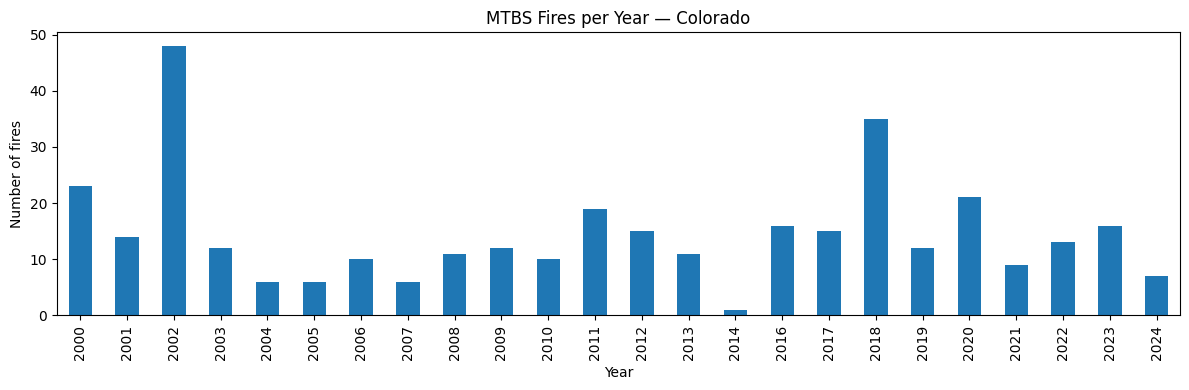

In [6]:
# Save GeoJSON of fire polygons
save_geojson(fires_fc, "mtbs_colorado.geojson")

# Quick summary: fires per year
fires_per_year = df_mtbs.groupby("fire_year").size().reset_index(name="count")
fires_per_year.plot(x="fire_year", y="count", kind="bar", figsize=(12, 4),
                    title="MTBS Fires per Year — Colorado", legend=False)
plt.xlabel("Year")
plt.ylabel("Number of fires")
plt.tight_layout()
plt.show()

---
## Step 2 — SRTM Topography (Elevation, Slope, Aspect)

**Source:** USGS Shuttle Radar Topography Mission (SRTM)  
**EE Asset:** `USGS/SRTMGL1_003`  
**What we extract:** Elevation (m), slope (degrees), aspect (degrees) at each fire centroid  
**Resolution:** 90 m (resampled from 30 m native for speed)

In [7]:
topo = build_topo_image()

# State-level summary
summary = summarize_topo_for_colorado(topo, colorado)
print("Colorado mean topography:")
for k, v in summary.items():
    print(f"  {k}: {v:.2f}")

Colorado mean topography:
  aspect: 161.08
  elevation: 2095.19
  slope: 3.27


In [8]:
# Sample topo at MTBS fire centroids
def make_centroid(f):
    return ee.Feature(f.geometry().centroid(30), {
        "fire_id":   f.get("Event_ID"),
        "fire_year": f.get("fire_year"),
        "label":     1
    })

centroids = fires_fc.map(make_centroid)
df_topo   = sample_topo_at_points(centroids, topo)
df_topo.to_csv("srtm_fire_centroids.csv", index=False)

print(f"Shape: {df_topo.shape}")
df_topo.head()

Shape: (348, 8)


,aspect,elevation,fire_id,fire_year,label,slope,longitude,latitude
0,61.183109,1938,CO3819510502420000409,2000,1,6.703963,-105.024061,38.194794
1,185.963043,2136,CO3707910730420010503,2001,1,11.051322,-107.303985,37.078278
2,125.945824,2119,CO3709810719920101012,2010,1,7.850494,-107.198882,37.097681
3,217.355820,3161,CO3743010682020130927,2013,1,18.573490,-106.821320,37.442904
4,50.700417,2287,CO3709810721320160910,2016,1,26.490746,-107.234456,37.109000


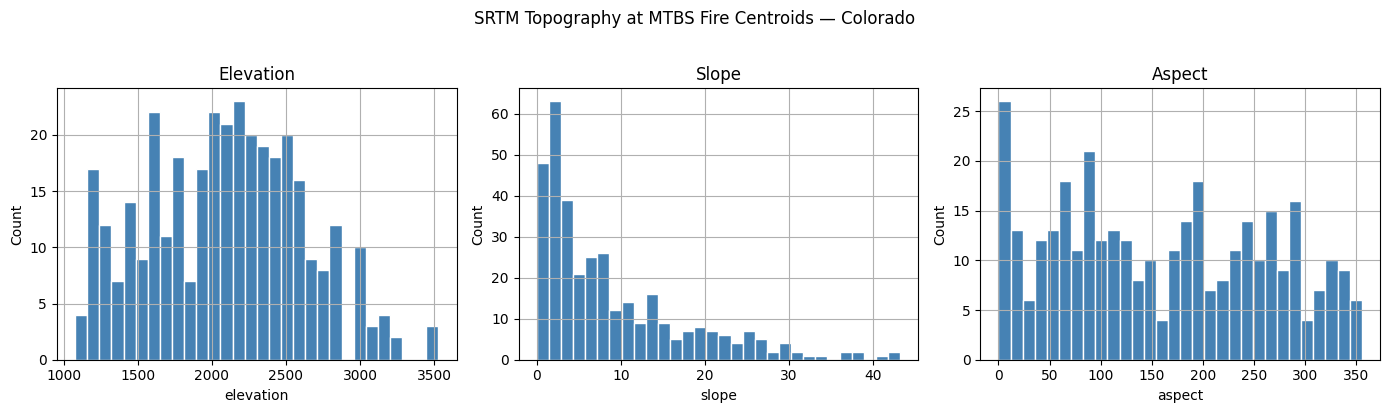

In [9]:
# Distributions of elevation, slope, aspect at fire locations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["elevation", "slope", "aspect"]):
    df_topo[col].dropna().hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.suptitle("SRTM Topography at MTBS Fire Centroids — Colorado", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 3 — GridMET Climate Data (2019–2021)

**Source:** University of Idaho GridMET  
**EE Asset:** `IDAHO_EPSCOR/GRIDMET`  
**What we extract:** Daily spatial means over Colorado for:
- `tmax_C` — maximum temperature (°C)
- `tmin_C` — minimum temperature (°C)
- `precip_mm` — precipitation (mm)
- `vpd_kPa` — vapor pressure deficit (kPa)
- `wind_ms` — wind speed (m/s)
- `erc` — energy release component (fire weather index)

**Outputs:** `gridmet_colorado_climate.csv` (daily), `gridmet_colorado_climate_monthly.csv` (monthly)

In [10]:
df_climate = extract_daily_means(
    start_date="2019-01-01",
    end_date="2021-12-31",
    boundary=colorado,
)
df_climate.to_csv("gridmet_colorado_climate.csv", index=False)

print(f"Shape: {df_climate.shape}")
print(f"Date range: {df_climate['date'].min()} → {df_climate['date'].max()}")
df_climate.head()

Shape: (1095, 7)
Date range: 2019-01-01 00:00:00 → 2021-12-30 00:00:00


,date,erc,precip_mm,vpd_kPa,wind_ms,tmax_C,tmin_C
0,2019-01-01,23.176946,0.624945,0.045753,2.955395,-9.493341,-21.263756
1,2019-01-02,27.046778,0.294068,0.189174,2.912529,-1.684085,-19.045551
2,2019-01-03,28.704132,0.313006,0.350954,3.433322,4.194687,-13.914776
3,2019-01-04,32.370264,0.112406,0.525460,3.107368,8.919906,-8.671981
4,2019-01-05,31.483810,1.128622,0.539894,3.043725,9.087733,-7.447331


In [ ]:
# Monthly aggregation
df_monthly = aggregate_monthly(df_climate)
df_monthly.to_csv("gridmet_colorado_climate_monthly.csv", index=False)

print(f"Monthly shape: {df_monthly.shape}")
df_monthly.head(12)

In [ ]:
# Plot daily tmax and VPD over the 3-year period
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df_climate["date"], df_climate["tmax_C"], color="tomato", linewidth=0.8)
axes[0].set_ylabel("Tmax (°C)")
axes[0].set_title("GridMET Daily Climate — Colorado (2019–2021)")

axes[1].plot(df_climate["date"], df_climate["vpd_kPa"], color="darkorange", linewidth=0.8)
axes[1].set_ylabel("VPD (kPa)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

---
## Step 4 — Fire-Weather Extraction at Fire Locations

Extract GridMET climate variables for each MTBS fire over a 7-day window before ignition.  
This produces a per-fire climate table suitable for modeling.

In [ ]:
# Extract fire-weather server-side using EE .map() — one API call instead of one per fire
gridmet = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")

def add_fire_weather_ee(f):
    fire_date = ee.Date(f.get("Ig_Date"))
    start     = fire_date.advance(-7, "day")
    end       = fire_date.advance(1, "day")
    region    = f.geometry().centroid(30).buffer(5000)

    window = gridmet.filterDate(start, end).select(
        ["tmmx", "tmmn", "pr", "vpd", "vs", "erc"]
    )

    stats = window.mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=4000,
        maxPixels=1e9,
        bestEffort=True,
    )

    return f.set(stats).set({
        "tmax_C": ee.Number(stats.get("tmmx")).subtract(273.15),
        "tmin_C": ee.Number(stats.get("tmmn")).subtract(273.15),
    })

fires_with_weather = fires_fc.map(add_fire_weather_ee)

# Pull all results in one .getInfo() call
info = fires_with_weather.getInfo()
weather_cols = ["Event_ID", "fire_year", "Ig_Date",
                "tmax_C", "tmin_C", "pr", "vpd", "vs", "erc"]

rows = []
for feat in info["features"]:
    props = feat["properties"]
    rows.append({c: props.get(c) for c in weather_cols})

df_fire_weather = pd.DataFrame(rows)
df_fire_weather.to_csv("gridmet_fire_weather.csv", index=False)

print(f"Fire-weather rows: {df_fire_weather.shape}")
df_fire_weather.head()

---
## Step 5 — Merge All Data Sources

Join MTBS fire attributes + SRTM topography + GridMET fire-weather into one analysis-ready table.

In [ ]:
# Merge MTBS + topo on fire_id / Event_ID
df_merged = df_mtbs.merge(
    df_topo.rename(columns={"fire_id": "Event_ID"}),
    on="Event_ID", how="left"
)

# Merge with fire-weather
df_merged = df_merged.merge(
    df_fire_weather.drop(columns=["fire_year", "Ig_Date"], errors="ignore"),
    on="Event_ID", how="left"
)

df_merged.to_csv("co_fires_merged.csv", index=False)

print(f"Merged table shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")
df_merged.head()

---
## Summary

| Output file | Contents |
|-------------|----------|
| `mtbs_colorado.csv` | MTBS fire attributes for Colorado 2000–2023 |
| `mtbs_colorado.geojson` | Fire polygon geometries |
| `srtm_fire_centroids.csv` | Elevation, slope, aspect at each fire centroid |
| `gridmet_colorado_climate.csv` | Daily GridMET means over Colorado 2019–2021 |
| `gridmet_colorado_climate_monthly.csv` | Monthly aggregated climate |
| `gridmet_fire_weather.csv` | Per-fire 7-day pre-ignition weather |
| `co_fires_merged.csv` | All sources joined — ready for EDA and modeling |

**Next step:** Open `fire_eda.ipynb` to explore and analyze the merged dataset.

---
## Visualization — Number of Fires per Year (2000–2026)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# Load MTBS CSV (already saved in Step 1)
df_mtbs = pd.read_csv("mtbs_colorado.csv")

# Count fires per year
fires_per_year = (
    df_mtbs.groupby("fire_year")
    .size()
    .reindex(range(2000, 2027), fill_value=0)
    .reset_index(name="count")
)
fires_per_year.columns = ["year", "count"]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    fires_per_year["year"],
    fires_per_year["count"],
    color="tomato",
    edgecolor="white",
    linewidth=0.6,
)

# Annotate each bar with its count
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.3,
            str(int(h)),
            ha="center", va="bottom", fontsize=8
        )

ax.set_title("Number of MTBS Fires in Colorado (2000–2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Fires", fontsize=11)
ax.set_xticks(fires_per_year["year"])
ax.set_xticklabels(fires_per_year["year"], rotation=45, ha="right")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fires_per_year.png", dpi=150)
plt.show()

print(f"Peak year: {fires_per_year.loc[fires_per_year['count'].idxmax(), 'year']} "
      f"({fires_per_year['count'].max()} fires)")